# Ergodic Trajectory within a specified convex domain

In [1]:
import Pkg; Pkg.activate("../"); Pkg.instantiate()

  Activating project at `~/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim`


In [2]:
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

In [3]:
using Plots, Revise, StaticArrays, Interpolations, LinearAlgebra

In [188]:
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/simulator_spatial.jl")
include("../src/Convex_bound_avoidance.jl")

Main.ConvexBoundAvoidance

## Spatial-only Matern-12 Kernel

In [189]:
# Define domain vars
dim = 100; # number of data points along each axis in the domain (defining a square domain)
xstart, xstop = 0, 25; # x-axis start and end positions
ystart, ystop = 0, 10; # y-axis start and end positions

σ_sq = 1.0
λₓ = 1/(4.0) 

env_data = SyntheticData.matern12_spatial(dim, xstart, xstop, ystart, ystop, σ_sq, λₓ);
# heatmap(range(xstart, stop=xstop, length=dim), range(ystart, stop=ystop, length=dim), env_data; c = :vik)
# title!("Synthetic Data: σ² = $(σ_sq), λₓ = $(λₓ)")

In [190]:
plotly();
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
plot!(clims=(-2,2))

In [191]:
# Create an ngpkf grid based on the data
# λₓ_wrong = 1/(2.5) 

σ_spatial = σ_sq
# l_spatial = 1/λₓ_wrong
l_spatial = 1/λₓ

res_factor = 0.4 #l_spatial / sqrt(2.0)

kern = NGPKF.MaternKernel(σ_spatial, l_spatial)

ngp_grid_x = range(extrema(env_data.X)..., step= res_factor )
ngp_grid_y = range(extrema(env_data.Y)..., step= res_factor )



# ngp_grid_x = range(extrema(env_data.X)..., length=10) # step= res_factor )
# ngp_grid_y = range(extrema(env_data.Y)..., length=10)# step= res_factor )

0.0:0.4:10.0

In [192]:
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

Main.NGPKF.NGPKFGrid{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{SVector{2, Float64}}, Hermitian{Float64, Matrix{Float64}}, Main.NGPKF.MaternKernel{Float64}}(0.0:0.4:24.8, 0.0:0.4:10.0, SVector{2, Float64}[[0.0, 0.0], [0.4, 0.0], [0.8, 0.0], [1.2, 0.0], [1.6, 0.0], [2.0, 0.0], [2.4, 0.0], [2.8, 0.0], [3.2, 0.0], [3.6, 0.0]  …  [21.2, 10.0], [21.6, 10.0], [22.0, 10.0], [22.4, 10.0], [22.8, 10.0], [23.2, 10.0], [23.6, 10.0], [24.0, 10.0], [24.4, 10.0], [24.8, 10.0]], Main.NGPKF.MaternKernel{Float64}(1.0, 4.0), [8.238163306308481 -4.280116567977607 … 1.5835949649823457e-7 5.120424345825411e-7; -4.280116567977607 11.276326456728125 … 3.895743207217191e-8 1.583594965098364e-7; … ; 1.5835949649823457e-7 3.895743207217191e-8 … 11.276326456728185 -4.280116567977641; 5.120424345825411e-7 1.583594965098364e-7 … -4.280116567977641 8.238163306308499])

In [193]:
size(ngp_grid_x), size(ngp_grid_y)

((63,), (26,))

In [194]:
@assert maximum(abs.(ngpkf_grid.invK)) < 10.0


LoadError: AssertionError: maximum(abs.(ngpkf_grid.invK)) < 10.0

In [195]:
# x0s = [@SVector[rand(ngpkf_grid.xs[2:(end-2)]), rand(ngpkf_grid.ys[2:(end-2)])] for i=1:1]
x0s = [@SVector[12.5, 5.0] for i=1:1]

1-element Vector{SVector{2, Float64}}:
 [12.5, 5.0]

In [196]:
[2, 4]

2-element Vector{Int64}:
 2
 4

In [197]:
SimulatorSpatial.measure(0.0, x0s, env_data; σ_meas = 0.05)

1-element Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}:
 Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}(0.0, [12.5, 5.0], 0.02102887280174147)

In [301]:
# Plot the convex shape to be explored
# Define vertices of a convex polygon (example: a square)

# Triangle 
vertices = [0.0 25.0 12.5;
    0.0 0.0 10]

# Shape 1
# vertices_1 = [5 20 22.5 22.5 20 5 2.5 2.5;
#             1.25 1.25 2.5 7.5 8.75 8.75 7.5 2.5]

# Shape 2
# vertices = [2.5 22.5 25 25 22.5 2.5 0 0;
#               0 0 2.5 7.5 10 10 7.5 2.5]

# # Shape 3
# vertices = [
#     2.0  5.0  15.0  20.0  18.0  4.0;
#     2.0  8.0  9.0   7.0   3.0   1.0
# ]




# Create a ConvexPolygon object
convex_polygon = ConvexBoundAvoidance.ConvexPolygon(vertices)

Main.ConvexBoundAvoidance.ConvexPolygon([0.0 25.0 12.5; 0.0 0.0 10.0], [-25.0 12.5 12.5; 0.0 -10.0 10.0])

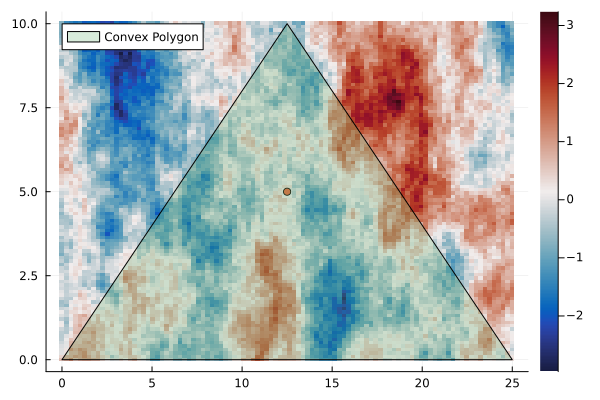

In [302]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
scatter!(first.(x0s), last.(x0s), label = "")
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.2, label="Convex Polygon")

In [303]:
ΔT = 5.0 / 60.0 # seconds
Tend = 1.0 # hours 
ts = 0.0:(ΔT):(Tend * 60)

0.0:0.08333333333333333:60.0

In [304]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(ΔT)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [305]:
using DifferentialEquations
using ForwardDiff

function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end

C = Cfun(0, 0)
R = Rfun(0, 0)
Q = 0.0
Clarity_decay(u,p,t) = (C^2 / R) * (1-u)^2 - Q * u^2
k = (C^2 / R)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end


function Forward_Simulate_Clarity(current_clarity, target_clarity; fn::Function = Clarity)
    """
    Forward simulate for maximum 10 seconds
    Here for now I only consider the spatiostatic environment 
    """    
    tspan = (0.0, 10.0) # 10 is just chosen to be a huge value for this problem
    u0 = current_clarity
    prob = ODEProblem(fn, u0, tspan)
    condition(u, t, integrator) = u ≥ target_clarity
    affect!(integrator) = terminate!(integrator)
    cb = DiscreteCallback(condition, affect!)
    sol = solve(prob, Tsit5(), callback = cb);
    return sol.t[end]
    
end

Forward_Simulate_Clarity (generic function with 1 method)

In [306]:
# Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

In [307]:
 δt = Forward_Simulate_Clarity(0.1, 0.2; fn = Clarity_decay)

0.42925145522571584

In [308]:
 δt = Clarity_delta_t(0.1, 0.2)

0.4166666666666667

In [309]:
 δt = Clarity_delta_new(0.1, 0.2)

0.4166666666666667

In [310]:
umax=30.0 * 60 / 1000

1.8

In [311]:
using LinearAlgebra, StatsBase

function ergo_controller3(t, xs, convex_polygon; 
        ergo_grid,
        ergo_q_map,
        traj,
        umax=30.0 * 60 / 1000,
        ΔT,
        kwargs...
        )

    target_q = 0.9 ; # * ones(size(ergo_q_map))

    target_spatial_dist = zeros(size(ergo_q_map))

    Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

    
    # Only explore the right-hand side of the environment
    for i in CartesianIndices(target_spatial_dist)
        if target_q > ergo_q_map[i]
            target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], target_q)
        else
            target_spatial_dist[i] = 0.0
        end
    end
    
    # Control input with convex boundary correction
    u = [ErgodicController.controller_single_integrator_cvx_bound(ergo_grid, x, traj, target_spatial_dist, convex_polygon; umax=umax, do_boundary_correction=true) for x in xs]
    
#     # Control input with rectangular boundary correction
#     u = [ErgodicController.controller_single_integrator(ergo_grid, x, traj, target_spatial_dist; umax=umax, do_boundary_correction=false) for x in xs]
    return u

end

ergo_controllers3 = [ergo_controller3 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller3)}:
 ergo_controller3 (generic function with 1 method)

In [312]:
ΔT = 5.0/120.0 # minutes
Tend = 0.1 # hours 
ts = 0.0:(ΔT):(240)
fuse_measurements_every_ΔT = 5.0 # minutes
recompute_controller_every_ΔT = 5.0 / 120.0 # minutes
σ_t = zeros(63, 26);

In [313]:
5.0/120.0

0.041666666666666664

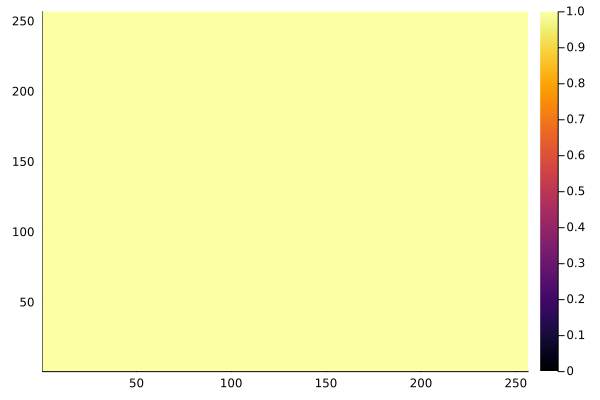

In [314]:
# Test the code 

w_hat = NGPKF.initialize(ngpkf_grid)
# Initial w_hat
# Based on w_hat, initialize current clarity
# 
# σ = KF.σ(w_hat)
q_map = NGPKF.clarity_map(ngpkf_grid, w_hat)

ergo_grid = SimulatorSpatial.ErgoGrid(ngpkf_grid, (256, 256))
ergo_q_map = SimulatorSpatial.ngpkf_to_ergo(ngpkf_grid, ergo_grid, q_map);

target_spatial_dist = zeros(size(ergo_q_map));

# Only assign target clarity  

# The whole domain
for i in CartesianIndices(target_spatial_dist)
    target_spatial_dist[i] = 1.0
end



# for i in CartesianIndices(target_spatial_dist)
#     if (i[1] >= 50 && i[2] <= 200) && (i[1] <= 200 && i[2] >= 50)
#         target_spatial_dist[i] = 1.0
#     end
    
#     #     if target_q > ergo_q_map[i]
# #         target_spatial_dist[i] = Forward_Simulate_Clarity(ergo_q_map[i], target_q; fn = Clarity_decay)
# #     else
# #         target_spatial_dist[i] = 0.0
# #     end
# # #         target_spatial_dist[i] = clarity_time(ergo_q_map[i], target_q, C_, R_, Qp)
# end

heatmap(target_spatial_dist', clims=(0, 1))
# polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
# plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.3, linecolor = "green", lw=3,label="")

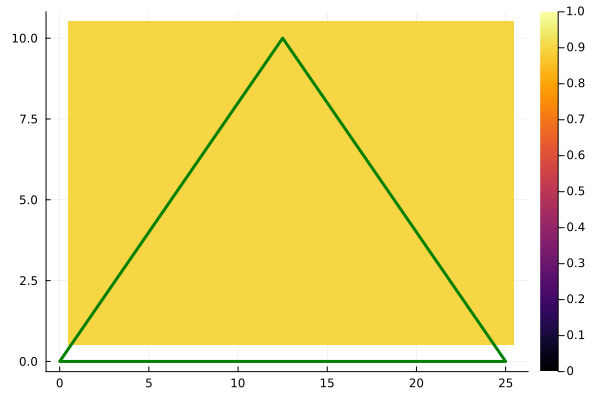

In [315]:
targetq_scaled_plot = ones(25, 10)
targetq_scaled_plot *= 0.9
heatmap(targetq_scaled_plot', clims=(0, 1))
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, linecolor = "green", lw=3,label="")

In [316]:
@time res_ergo =  SimulatorSpatial.simulate_spatial_cvx_bound(ts, x0s, ergo_controller3, convex_polygon; 
    ngpkf_grid=ngpkf_grid, 
    EnvDataSpatial=env_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|                                         |  ETA: N/A
Progress:   1%|▎                                        |  ETA: 0:01:19
Progress:   1%|▍                                        |  ETA: 0:01:17
Progress:   2%|▋                                        |  ETA: 0:01:17


Inside prediction of NGP


Progress:   2%|▉                                        |  ETA: 0:01:16
Progress:   3%|█                                        |  ETA: 0:01:45
Progress:   3%|█▎                                       |  ETA: 0:01:39
Progress:   4%|█▌                                       |  ETA: 0:01:35
Progress:   4%|█▋                                       |  ETA: 0:01:32


Inside prediction of NGP


Progress:   5%|█▉                                       |  ETA: 0:01:46
Progress:   5%|██▏                                      |  ETA: 0:01:42
Progress:   6%|██▎                                      |  ETA: 0:01:39
Progress:   6%|██▌                                      |  ETA: 0:01:36


...

Inside prediction of NGP


Progress:  98%|████████████████████████████████████████▎|  ETA: 0:00:02
Progress:  99%|████████████████████████████████████████▌|  ETA: 0:00:01
Progress:  99%|████████████████████████████████████████▋|  ETA: 0:00:01
Progress: 100%|████████████████████████████████████████▉|  ETA: 0:00:00


109.063666 seconds (3.89 G allocations: 91.303 GiB, 19.75% gc time, 0.23% compilation time: 78% of which was recompilation)


Progress: 100%|█████████████████████████████████████████| Time: 0:01:48


Main.SimulatorSpatial.SimResult{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}, Vector{Float64}, Vector{Main.KF.KFState{Vector{Float64}, UpperTriangular{Float64, Matrix{Float64}}}}, Vector{Matrix{Float64}}}(0.0:0.041666666666666664:240.0, Vector{SVector{2, Float64}}[[[12.5, 5.0]], [[12.554593870153122, 5.05142479306428]], [[12.577743816116413, 5.122762581100472]], [[12.600835751748571, 5.194119168103777]], [[12.628869026804173, 5.26368306311877]], [[12.661954598296944, 5.330990900396436]], [[12.682383926746285, 5.403154897923659]], [[12.701505834099203, 5.475676292416501]], [[12.721889361594018, 5.547853240307556]], [[12.74425321995335, 5.619441352723541]]  …  [[20.18918928303956, 3.1967699692356484]], [[20.19056338775729, 3.1956880698341057]], [[20.19193529857131, 3.1946075490171135]

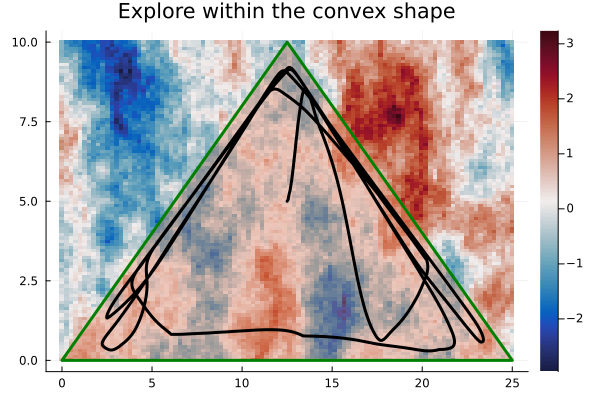

In [317]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.3, linecolor = "green", lw=3,label="")
for i=1:length(x0s)
    x = [r[i][1] for r in res_ergo.xs]
    y = [r[i][2] for r in res_ergo.xs]
    plot!(x,y, linewidth=3, color=:black, label = "")
end
plot!()

# # Define the range for x
# x1 = 5:0.1:20
# x3 = 5:0.1:20
# y2 = 2.0:0.1:8.0

# # Define the constant y
# y1 = 2 .* ones(length(x1))
# y3 = 8 .* ones(length(x1))
# x2 = 5 .* ones(length(y2))
# x4 = 20 .* ones(length(y2))
                    
# # Plot the line
# # Top left box
# plot!(x1, y1, label="", lw=3, color = "green")
# plot!(x2, y2, label="", lw=3, color = "green")
# plot!(x3, y3, label="", lw=3, color = "green")
# plot!(x4, y2, label="", lw=3 ,color = "green")


title!("Explore within the convex shape")

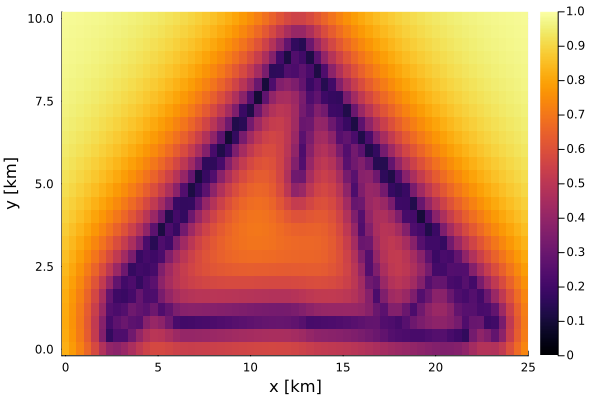

In [318]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)

┌ Info: Saved animation to
└ /home/dasc-group/KalebData/PhDResearch/CPS_Project/adaptive-ocean-exploration-sim/notebooks/tmp.gif


Plots.AnimatedGif("/home/dasc-group/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim/notebooks/tmp.gif")
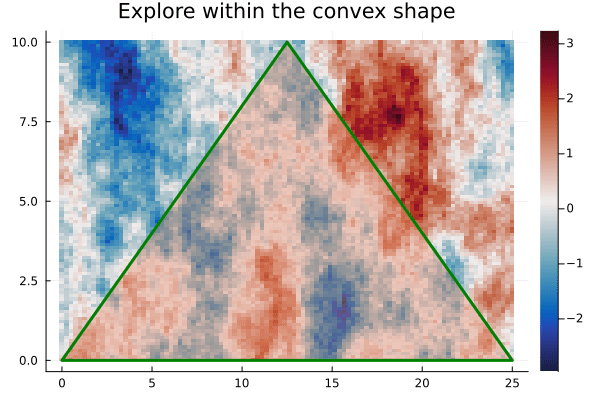

In [319]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
    
    polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.3, linecolor = "green", lw=3,label="")

    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black, label="")
    end
    plot!()
    title!("Explore within the convex shape")
end

In [ ]:
targetq_scaled_plot = ones(25, 10)
targetq_scaled_plot *= 0.9
heatmap(targetq_scaled_plot', clims=(0, 1))
polygon_vertices = hcat(convex_polygon.vertices, convex_polygon.vertices[:, 1])  # Close the polygon
plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, linecolor = "green", lw=3,label="")

In [ ]:
# Comparing two target clarities
gr()
@gif for i=1:length(res_ergo.q_target_maps)
    p0 = heatmap(targetq_scaled_plot', clims=(0, 1))
    p1 = heatmap(res_ergo.q_target_maps[i]', title = "Target Clarity weighted 1")
    p2 = heatmap(res_ergo_exp.q_target_maps[i]', clims=(0, 1), title = "Target clarity weighted exponential")
    plot(p0, p1, p2, layout=@layout[a b c], size=(2000, 350))
#     title!("Weighted coverage")
end

In [37]:
u1 = Float64[]
u2 = Float64[]
speed = Float64[]

for i=1:length(res_ergo.us)
    push!(u1, res_ergo.us[i][1][1])
    push!(u2, res_ergo.us[i][1][2])
    push!(speed, norm(res_ergo.us[i][1]))
end

In [54]:
plot(speed)
ylims!(0., 5.0)

length(speed)
interpolated_times = range(0, stop=170, length=2041)
interpolated_speeds = [v_itp(t) for t in interpolated_times]

2041-element Vector{Float64}:
 2.315000057220459
 2.315000057220459
 2.315000057220459
 2.3150000572204594
 2.315000057220459
 2.315000057220459
 2.3150000572204585
 2.315000057220459
 2.315000057220459
 2.315000057220459
 2.315000057220459
 2.315000057220459
 2.315000057220459
 ⋮
 2.9093207427320578
 2.9284705506436155
 2.9476203585551803
 2.9667701664667447
 2.985919974378303
 3.0050697822898678
 3.024219590201432
 3.043369398112991
 3.0625192060245547
 3.0816690139361196
 3.100818821847678
 3.1199686297592426

In [ ]:
v_itp

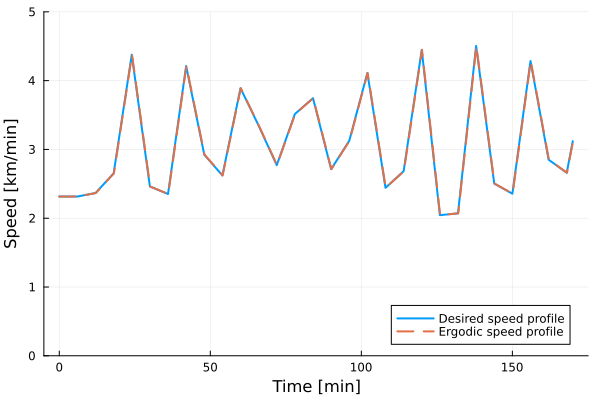

In [71]:
gr()
plot(interpolated_times, interpolated_speeds, lw=2.0, label="Desired speed profile")
plot!(interpolated_times, speed, linestyle=:dash, lw=2.0, label ="Ergodic speed profile")
ylims!(0., 5.0)
xlabel!("Time [min]")
ylabel!("Speed [km/min]")

┌ Info: Saved animation to
└ /home/dasc-group/KalebData/PhDResearch/CPS_Project/adaptive-ocean-exploration-sim/tmp.gif


Plots.AnimatedGif("/home/dasc-group/Kaleb_Data/PhD_Research/CPS_Project/adaptive-ocean-exploration-sim/tmp.gif")
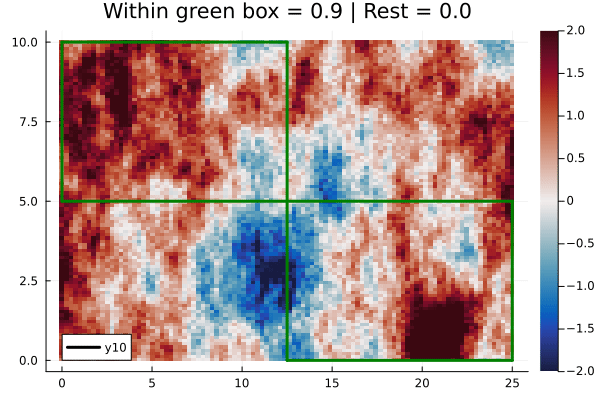

In [96]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))

    # Define the range for x
    x1 = 0:0.1:12.5
    x3 = 0:0.1:12.5
    y2 = 5.0:0.1:10.0
    y4 = 5.0:0.1:10.0
    x5 = 12.5:0.1:25
    y7 = 0:0.1:5.0
    # Define the constant y
    y1 = 5 .* ones(length(x1))
    y3 = 10 .* ones(length(x1))
    x2 = 12.5 .* ones(length(y2))
    x4 = 0.0 .* ones(length(y2))
    y5 = 0.0 .* ones(length(x5))
    y6 = 5.0 .* ones(length(x5))
    x7 = 12.5 .* ones(length(y7))
    x8 = 25 .* ones(length(y7))

    # Plot the line
    # Top left box
    plot!(x1, y1, label="", lw=3, color = "green")
    plot!(x2, y2, label="", lw=3, color = "green")
    plot!(x3, y3, label="", lw=3, color = "green")
    plot!(x4, y4, label="", lw=3 ,color = "green")

    # Bottom right box 
    plot!(x5, y5, label="", lw=3, color = "green")
    plot!(x5, y6, label="", lw=3, color = "green")
    plot!(x7, y7, label="", lw=3, color = "green")
    plot!(x8, y7, label="", lw=3 ,color = "green")

    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black)
    end
    plot!()
    title!("Within green box = 0.9 | Rest = 0.0")
end

# # Plot line 
# # Define the constant y
# # Define the range for x
# x1 = 0:0.1:25

# # Define the constant y
# y1 = 5 .* ones(length(x1))

# # Plot the line
# plot!(x1, y1, label="", lw=5)


In [82]:
size(res_ergo.w_hats)

(18,)

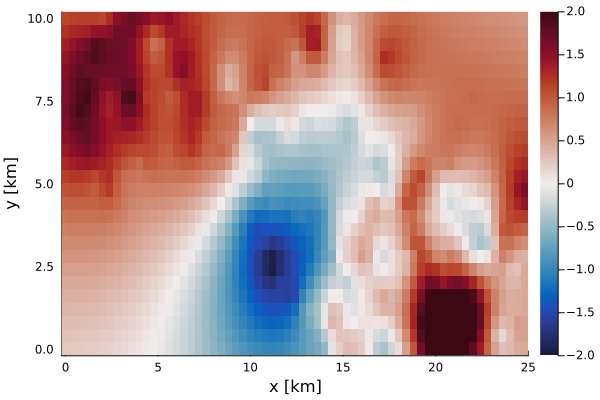

In [98]:
gr()

p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2))


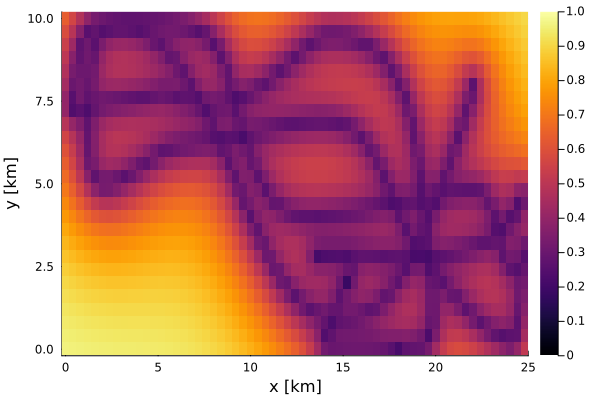

In [99]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)
# for i=1:length(x0s)
#     x = [r[i][1] for r in res_ergo.xs]
#     y = [r[i][2] for r in res_ergo.xs]
#     plot!(x, y, linewidth=3)
# end
plot!()

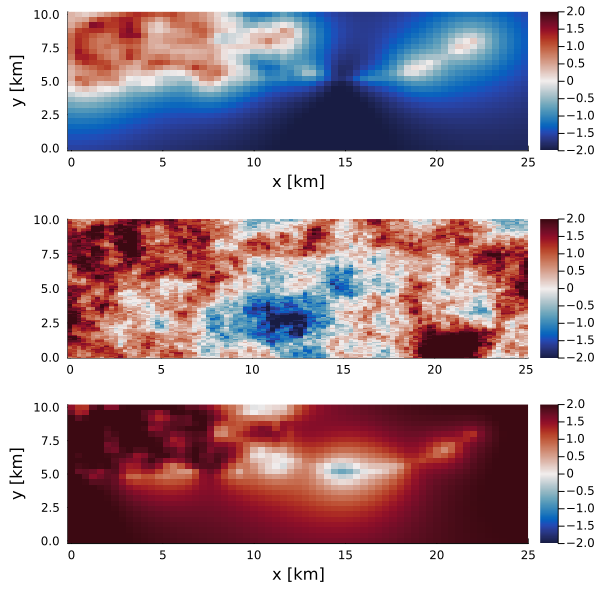

In [85]:
gr()

p1 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_min=true)
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_max=true)
p3 = heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
    
plot(p1, p3, p2, layout = (@layout [a;b; c]), size=[600, 600])

In [258]:
# Compute RMSE

Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)

M = reshape(KF.μ(res_ergo.w_hats[end]), Nx, Ny)
heatmap(M',colormap=:balance, clims=(-2,2) )
x_new = 0:0.4:25
y_new = 0:0.4:10
Data_sampled = [env_data.itp_w(xi, yi) for yi in y_new, xi in x_new]
Diff = M' .- Data_sampled
rmse = sqrt(mean(Diff .^ 2))

0.38120928181387576

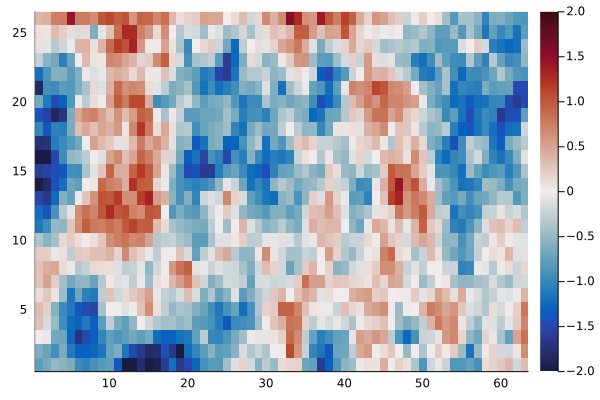

In [259]:
heatmap(Data_sampled,colormap=:balance, clims=(-2,2))

In [260]:
# Compute Precision

σ_prec = KF.σ(res_ergo.w_hats[end])
M_prec = reshape(σ_prec, Nx, Ny)
precision = sum(M_prec)/length(M_prec)

0.5161172120847358

In [261]:
using LinearAlgebra, StatsBase

mean_deficit_1 = [mean(map( c -> max(0, 1.0 - c), q )) for q in res_ergo.ergo_q_maps]
mean_deficit_1[end]

0.20937851230359755

In [262]:
ts = range(1, 100, 20)
time = collect(ts)

20-element Vector{Float64}:
   1.0
   6.2105263157894735
  11.421052631578947
  16.63157894736842
  21.842105263157894
  27.05263157894737
  32.26315789473684
  37.473684210526315
  42.68421052631579
  47.89473684210526
  53.10526315789474
  58.31578947368421
  63.526315789473685
  68.73684210526316
  73.94736842105263
  79.15789473684211
  84.36842105263158
  89.57894736842105
  94.78947368421052
 100.0

In [263]:
# plot(res_ergo.w_hat_ts, mean_deficit_1, marker=:dot)
gr()
plot()
plot!(time, mean_deficit_1, marker=:dot)
ylabel!("Clarity Deficit[0,1]")
xlabel!("Time [min]")
ylims!(0., 0.6)

attempt to save state beyond implementation limit
attempt to save state beyond implementation limit
